In [1]:

import PIL
import PIL.Image
import tensorflow as tf
import pathlib

import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_dir = pathlib.Path('Data/Processed_data')
print(data_dir)

image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

Data\Processed_data
1211


In [3]:
batch_size = 6
img_height = 244
img_width = 244

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.3,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 1211 files belonging to 2 classes.
Using 848 files for training.
Found 1211 files belonging to 2 classes.
Using 363 files for validation.


In [4]:
num_classes = 2

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255),
  tf.keras.layers.Conv2D(16, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(16, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(16, 3, activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(), 
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes)
])

In [5]:
model.compile(
  optimizer='adam',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy'])

In [6]:
model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=4
)

Epoch 1/4
142/142 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.8184 - loss: 0.4782 - val_accuracy: 0.8953 - val_loss: 0.2568
Epoch 2/4
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9281 - loss: 0.1961 - val_accuracy: 0.9725 - val_loss: 0.1229
Epoch 3/4
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.9682 - loss: 0.0778 - val_accuracy: 0.9807 - val_loss: 0.0612
Epoch 4/4
142/142 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9870 - loss: 0.0487 - val_accuracy: 0.9642 - val_loss: 0.1220


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 244, 244, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 242, 242, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 121, 121, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 119, 119, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 59, 59, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 57, 57, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,833,320 (18.44 MB)

 Trainable params: 1,611,106 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,222,214 (12.29 MB)

In [8]:
model.evaluate(
  val_ds
)

61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9642 - loss: 0.1220


[0.12204204499721527, 0.9641873240470886]

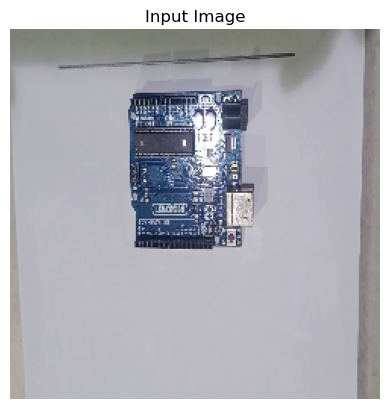

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Logits: [[-2.1960688  1.8912189]]
Probabilities: [0.01650762 0.98349243]
Predicted class index: 1
Predicted label: Pass_data
Confidence: 0.98349243


In [ ]:
# img_path = "Data/F1_Test/F1_images/F1_Pass/F1_Horiz_00110.jpg"
img_path = "Data/Processed_data/Pass_data/Pass_env2_00019.jpg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

logits = model.predict(img_array)
probs = tf.nn.softmax(logits[0]).numpy()

pred_class = np.argmax(probs)
confidence = probs[pred_class]

print("Logits:", logits)
print("Probabilities:", probs)
print("Predicted class index:", pred_class)
print("Predicted label:", train_ds.class_names[pred_class])
print("Confidence:", confidence)

In [10]:
model.save("Export/ot_model.keras")

In [11]:
import os
os.makedirs("Export", exist_ok=True)

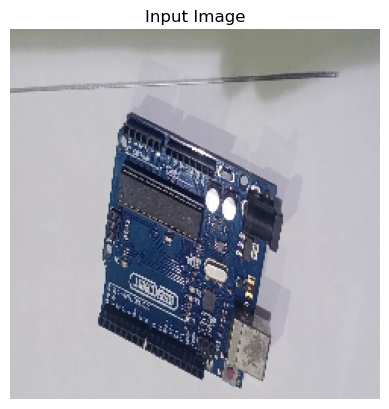

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Logits: [[ 0.67005086 -2.4293072 ]]
Probabilities: [0.9568662  0.04313374]
Predicted class index: 0
Predicted label: Fail_data
Confidence: 0.9568662


In [ ]:
img_path = "Data/Processed_data/Fail_data/Fail_env2_00029.jpg"
# img_path = "Data/F1_Test/F1_images/F1_Fail/F1_None_00110.jpg"

img = tf.keras.utils.load_img(
    img_path,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

loaded_model = tf.keras.models.load_model("Export/ot_model.keras")
logits = loaded_model.predict(img_array)
probs = tf.nn.softmax(logits[0]).numpy()

pred_class = np.argmax(probs)
confidence = probs[pred_class]

print("Logits:", logits)
print("Probabilities:", probs)
print("Predicted class index:", pred_class)
print("Predicted label:", train_ds.class_names[pred_class])
print("Confidence:", confidence)